In [20]:
import numpy as np 
import pandas as pd 

In [21]:
df_yield = pd.read_csv('./data/raw.csv')
df_yield.shape

(26, 8)

In [22]:
df_yield.head()

,m_B,t_RT1,T_drawH,m_C,t_RT2,T_methyl,p_A,yield
0,2.66,8.45,-39.0,3.15,121.2,-30,39.66,60.34
1,2.65,4.23,-39.0,3.15,121.2,-30,14.35,85.65
2,2.66,2.07,-39.0,3.15,121.2,-30,14.10,85.90
3,2.13,4.81,-39.0,3.15,121.2,-30,42.95,57.05
4,3.13,3.70,-39.0,3.15,121.2,-30,11.09,88.91


In [23]:
df_yield.describe()

,m_B,t_RT1,T_drawH,m_C,t_RT2,T_methyl,p_A,yield
count,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000
mean,2.474231,13.547692,-31.492308,2.601538,108.016538,-34.769231,29.356538,70.464615
std,0.309505,12.447223,6.955971,0.568477,77.542448,12.339555,16.418366,16.479441
min,2.070000,2.070000,-39.000000,0.710000,3.850000,-65.000000,8.390000,45.970000
25%,2.135000,4.727500,-35.000000,2.340000,29.127500,-35.000000,13.627500,57.075000
50%,2.625000,9.100000,-34.000000,2.580000,121.200000,-33.000000,32.830000,65.780000
75%,2.687500,9.362500,-31.000000,3.150000,130.625000,-30.000000,42.925000,86.372500
max,3.130000,36.570000,-15.000000,3.150000,278.600000,-12.000000,54.050000,91.610000


In [24]:
df_yield.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   m_B       26 non-null     float64
 1   t_RT1     26 non-null     float64
 2   T_drawH   26 non-null     float64
 3   m_C       26 non-null     float64
 4   t_RT2     26 non-null     float64
 5   T_methyl  26 non-null     int64  
 6   p_A       26 non-null     float64
 7   yield     26 non-null     float64
dtypes: float64(7), int64(1)
memory usage: 1.8 KB


In [25]:
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt

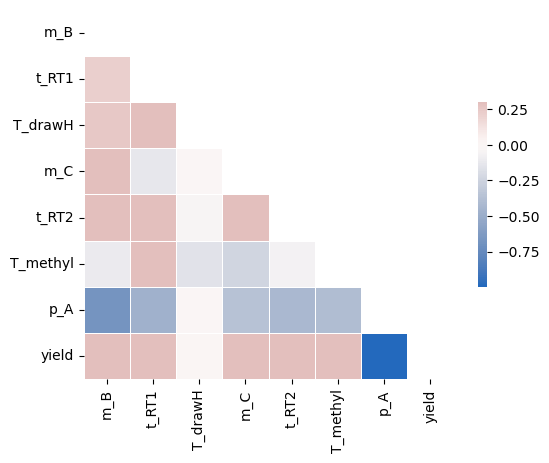

In [43]:
correlation_data=df_yield.select_dtypes(include=[np.number]).corr()
mask = np.zeros_like(correlation_data, dtype=bool)
mask[np.triu_indices_from(mask)] = True
f, ax = plt.subplots()
# Generate a custom diverging colormap
cmap = sns.palette="vlag"
# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlation_data, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5});

In [27]:
_features = df_yield.drop(['yield'], axis=1)
label = df_yield['yield']

In [28]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features=scaler.fit_transform(_features) 

In [29]:
from sklearn.model_selection import train_test_split

train_data, test_data, train_labels, test_labels = train_test_split(features, label, test_size=0.3, random_state=42)

In [30]:
from sklearn.metrics import r2_score
def compare_models(model):
    model_name = model.__class__.__name__
    fit=model.fit(train_data,train_labels)
    y_pred=fit.predict(test_data)
    r2=r2_score(test_labels,y_pred)
    return([model_name,r2])

In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn import svm
from sklearn.tree import DecisionTreeRegressor

models = [
    GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=0),
     RandomForestRegressor(n_estimators=200, max_depth=3, random_state=0),
    svm.SVR(),
   DecisionTreeRegressor()
]

In [32]:
model_train=list(map(compare_models,models)) 

In [33]:
print(*model_train, sep = "\n")

['GradientBoostingRegressor', 0.9579126542456812]
['RandomForestRegressor', 0.8896140722765216]
['SVR', -1.789211768577636]
['DecisionTreeRegressor', 0.9934132415080679]


In [34]:
test_df=pd.DataFrame(test_data, columns=_features.columns) 

In [35]:
clf=DecisionTreeRegressor()
model=clf.fit(train_data,train_labels)

test_df["yield_predicted"]= model.predict(test_data)
test_df["yield_actual"]=pd.DataFrame(test_labels)["yield"].tolist()

In [36]:
r2_score(test_df.yield_actual, test_df.yield_predicted)

0.905796658202367

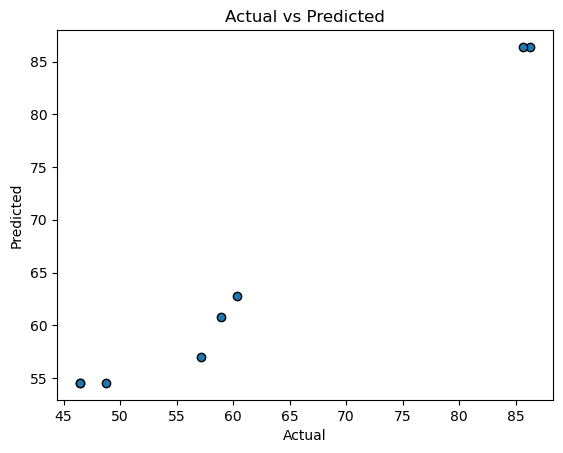

In [37]:
# So let's run the model actual values against the predicted ones 

fig, ax = plt.subplots() 

ax.scatter(test_df["yield_actual"], test_df["yield_predicted"],edgecolors=(0, 0, 0))

ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.set_title("Actual vs Predicted")
plt.show()

In [38]:
def adjusted_r_squared(y,yhat,x):
    score=1- (((1-(r2_score(y,yhat)))*(len(y)-1))/(len(y)-x.shape[1]-2))
    return score

adjusted_r_squared(test_df.yield_actual,test_df.yield_predicted,test_df)

1.2198077975278103

In [40]:
varimp= {'imp':model.feature_importances_,'names': _features.columns}

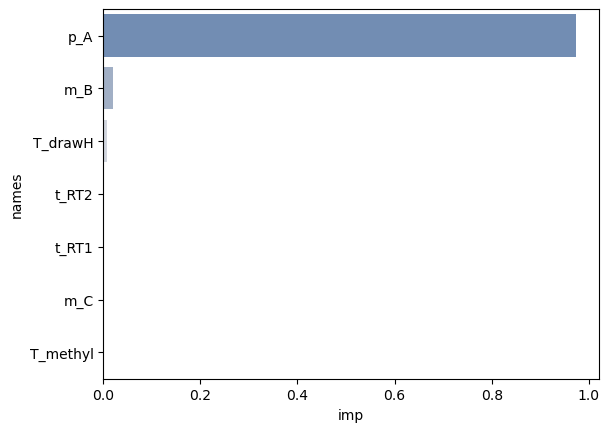

In [41]:
fig, ax = plt.subplots()
df=pd.DataFrame.from_dict(varimp)
df.sort_values(ascending=False, by=["imp"], inplace=True)
df=df.dropna()
sns.barplot(x="imp",y="names",palette="vlag",data=df, orient="h",ax=ax);

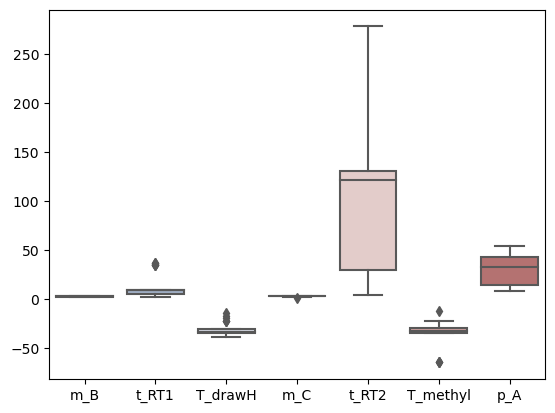

In [42]:
#Boxplot that shows yield for each item 

fig, ax = plt.subplots()
sns.boxplot(palette="vlag",data=_features, ax=ax);